In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('./btcusdt_1h.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# ATR parameters
atr_period = 50
atr_multiplier = 2  # n in High + n*ATR and Low - n*ATR
brokerage_cost=0.001

def calculate_atr(high, low, close, period):
    high_low = high - low
    high_close_prev = np.abs(high - close.shift())
    low_close_prev = np.abs(low - close.shift())
    true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    atr = true_range.rolling(window=period).mean()
    return atr

# Calculate ATR
df['ATR'] = calculate_atr(df['high'], df['low'], df['close'], atr_period)

# Calculate entry thresholds
df['Long_Threshold'] = df['high'] + atr_multiplier * df['ATR']
df['Short_Threshold'] = df['low'] - atr_multiplier * df['ATR']

# Calculate 50-period Simple Moving Average (SMA) for trend filter
df['SMA50'] = df['close'].rolling(window=50).mean()

# Function to generate positions considering brokerage costs
#def generate_positions(df, rsi_overbought=70, rsi_oversold=30, brokerage_cost=0.001):
df['Position'] = 0  # Initialize all positions as neutral
df['Entry_Price'] = np.nan  # To store entry prices
df['Exit_Price'] = np.nan  # To store exit prices

#if close price goes above long_threshhold and SMA then Long position
#if close price goes below short_threshhold and SMA then Short position
for i in range(1, len(df)):
    # Entry conditions
    if df['close'].iloc[i] > df['Long_Threshold'].iloc[i - 1] and df['close'].iloc[i] > df['SMA50'].iloc[i] and df['Position'].iloc[i-1] == 0:
        # Going long
        df['Position'].at[i] = 1  # Long position
        df['Entry_Price'].at[i] = df['close'].iloc[i] #* (1 + brokerage_cost)  # Account for brokerage on entry

    elif df['close'].iloc[i] < df['Short_Threshold'].iloc[i - 1] and df['close'].iloc[i] < df['SMA50'].iloc[i] and df['Position'].iloc[i-1] == 0:
        # Going short
        df['Position'].at[i] = -1  # Short position
        df['Entry_Price'].at[i] = df['close'].iloc[i] #* (1 - brokerage_cost)  # Account for brokerage on entry
    
    # Exit conditions
    if df['Position'].iloc[i-1] == 1:  # Currently long
        # Exit long if RSI crosses 50 or if price falls below the stop-loss
        if not (df['close'].iloc[i] > df['Long_Threshold'].iloc[i - 1] and df['close'].iloc[i] > df['SMA50'].iloc[i]):
            exit_price = df['close'].iloc[i] #* (1 - brokerage_cost)  # Account for brokerage on exit
            if exit_price > df['Entry_Price'].iloc[i-1]*(1+brokerage_cost):  # Ensure profit covers brokerage
                df['Position'].at[i] = 0  # Exit position
                df['Exit_Price'].at[i] = exit_price
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=1
        else:
            df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
            df['Position'].at[i]=1
    
    elif df['Position'].iloc[i-1] == -1:  # Currently short
        # Exit short if RSI crosses 50 or if price rises above the stop-loss
        if not (df['close'].iloc[i] < df['Short_Threshold'].iloc[i - 1] and df['close'].iloc[i] < df['SMA50'].iloc[i]) :
            exit_price = df['close'].iloc[i] #* (1 + brokerage_cost)  # Account for brokerage on exit
            if exit_price < df['Entry_Price'].iloc[i-1]*(1-brokerage_cost):  # Ensure profit covers brokerage
                df['Position'].at[i] = 0  # Exit position
                df['Exit_Price'].at[i] = exit_price
            else:
                df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
                df['Position'].at[i]=-1
        else:
            df['Entry_Price'].at[i]=df['Entry_Price'].at[i-1]
            df['Position'].at[i]=-1
                

    #return df

/tmp/ipykernel_230869/3044590739.py:30: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '65.16072000001805' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[i,'trades']=profit_loss


Gross Profit: 141795.28
Net Profit: 141072.66
Gross Loss: -722.62
Total Closed Trades: 2367.00
Number of Winning Trades: 2076.00
Number of Losing Trades: 291.00
Average Winning Trade (USDT): 68.30
Average Losing Trade (USDT): -2.48
Largest Winning Trade (USDT): 966.98
Largest Losing Trade (USDT): -5.32
Max Drawdown (USDT): -134.00
Sharpe Ratio: 0.02
Sortino Ratio: 0.09


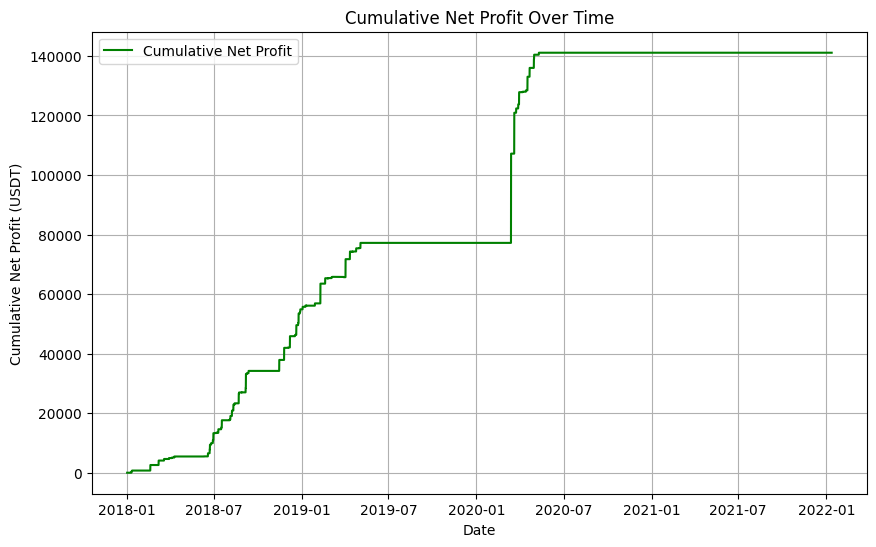

In [43]:
# Initialize variables for tracking trades and capital invested
df['trades']=0
df['num_trades']=0
trades = []
current_capital = 100000  # Track the current capital
prev_position = 0  # Track the current position (1 for long, -1 for short, 0 for neutral)
entry_price = None  # Track entry price for calculating profit/loss
brokerage = 0.1/100 #0.1%

# Iterate over the DataFrame to capture trade profits/losses
for i in range(1, len(df)):
    # Check if position changes
    if df['Position'].iloc[i] != prev_position:
        # Exiting long position
        if prev_position == 1:
            exit_price=(df['close'].iloc[i])*(1-brokerage)
            profit_loss = (exit_price - entry_price) * (current_capital // entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital // entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Exiting short position
        elif prev_position == -1:
            exit_price=(df['close'].iloc[i])*(1+brokerage)
            profit_loss = (entry_price - exit_price) * (current_capital // entry_price)
            trades.append(profit_loss)  # Append the realized profit/loss
            df.loc[i,'trades']=profit_loss
            df.loc[i,'num_trades']=current_capital // entry_price
            current_capital += profit_loss  # Update current capital
            prev_position = df['Position'].iloc[i]  # Update previoous position
            entry_price = None  # Reset entry price
        
        # Entering long position
        if df['Position'].iloc[i] == 1:
            entry_price = (df['close'].iloc[i])*(1+brokerage)  # Capture entry price for long
            prev_position = 1  # Update to long position
        
        # Entering short position
        elif df['Position'].iloc[i] == -1:
            entry_price = (df['close'].iloc[i])*(1-brokerage)  # Capture entry price for short
            prev_position = -1  # Update to short position

winning_trades = df[df['trades'] > 0]
losing_trades = df[df['trades'] < 0]
# Sum the 'num_trades' column for all winning trades
num_winning_trades = winning_trades['num_trades'].sum()
num_losing_trades = losing_trades['num_trades'].sum()
# Count total trades and calculate other metrics
gross_profit = winning_trades['trades'].sum()
gross_loss = losing_trades['trades'].sum()

average_winning_trade = (winning_trades['trades'].sum())/(winning_trades['num_trades'].sum()) if num_winning_trades > 0 else 0
average_losing_trade = (losing_trades['trades'].sum())/(losing_trades['num_trades'].sum()) if num_losing_trades > 0 else 0
largest_winning_trade = (winning_trades['trades']/winning_trades['num_trades']).max() if num_winning_trades > 0 else 0
largest_losing_trade = (losing_trades['trades']/losing_trades['num_trades']).min() if num_losing_trades > 0 else 0
net_profit=gross_profit+gross_loss

# Calculate cumulative net profit over time for plotting
df['Cumulative_Profit_Loss'] = df['trades'].cumsum().fillna(0)  # Fill missing values with 0
df['Returns'] = (df['Cumulative_Profit_Loss']+100000).pct_change().fillna(0)

# Risk-free rate 
risk_free_rate = 0  
days_in_year = 365  # Approximate number of trading days in a year
daily_risk_free_rate = (1 + risk_free_rate) ** (1 / days_in_year) - 1
# Calculate average daily return and standard deviation of daily returns
average_return = df['Returns'].mean()
std_dev_return = df['Returns'].std()
# Calculate the Sharpe Ratio
sharpe_ratio = (average_return - daily_risk_free_rate) / std_dev_return

# Filter the negative returns (downside returns)
negative_returns = df[df['Returns'] < daily_risk_free_rate]['Returns']
# Calculate downside deviation (standard deviation of negative returns)
downside_deviation = negative_returns.std()
# Calculate the Sortino Ratio
sortino_ratio = (average_return - daily_risk_free_rate) / downside_deviation

df['Portfolio']=df['Cumulative_Profit_Loss']+100000
#Calculate the running maximum of the portfolio
df['Peak'] = df['Portfolio'].cummax()
#Calculate the drawdown
df['Drawdown'] = (df['Peak'] - df['Portfolio']) / df['Peak']
#Convert drawdown to percentage
df['Drawdown_pct'] = df['Drawdown'] * 100
# Find the maximum drawdown
max_drawdown = df['Drawdown_pct'].max()
drawdown=(df['Portfolio']-df['Peak']).min()
# Output all metrics
metrics = {
    "Gross Profit": gross_profit,
    "Net Profit": net_profit,
    "Gross Loss": gross_loss,
    "Total Closed Trades": num_winning_trades+num_losing_trades,
    "Number of Winning Trades": num_winning_trades,
    "Number of Losing Trades": num_losing_trades,
    "Average Winning Trade (USDT)": average_winning_trade,
    "Average Losing Trade (USDT)": average_losing_trade,
    "Largest Winning Trade (USDT)": largest_winning_trade,
    "Largest Losing Trade (USDT)": largest_losing_trade,
    "Max Drawdown (USDT)": drawdown,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

# Plot net profit over time
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['Cumulative_Profit_Loss'], label='Cumulative Net Profit', color='g')
plt.title('Cumulative Net Profit Over Time')
plt.xlabel('Date')
plt.ylabel('Cumulative Net Profit (USDT)')
plt.grid(True)
plt.legend()
plt.show()